# 小批量梯度下降
Batch vs. mini-batch gradient descent
- batch 批量梯度下降 ：同时处理整个训练集批次.对训练集的一轮处理只能得到一步梯度逼近。
- mini-batch 小批量：每次只处理一个小批量样例$X\{t\} Y\{t\}$
    - 每轮处理可以得到$\frac{m}{n_{batch}}$步梯度逼近，其中m是样本总数，${n_{batch}}$是每个小批量的样本数

大括号{t}代表不同的小批量样例，注意维度问题  
- 一共有5,000,000个样本，每个batch有1000个样本，共5000个batch
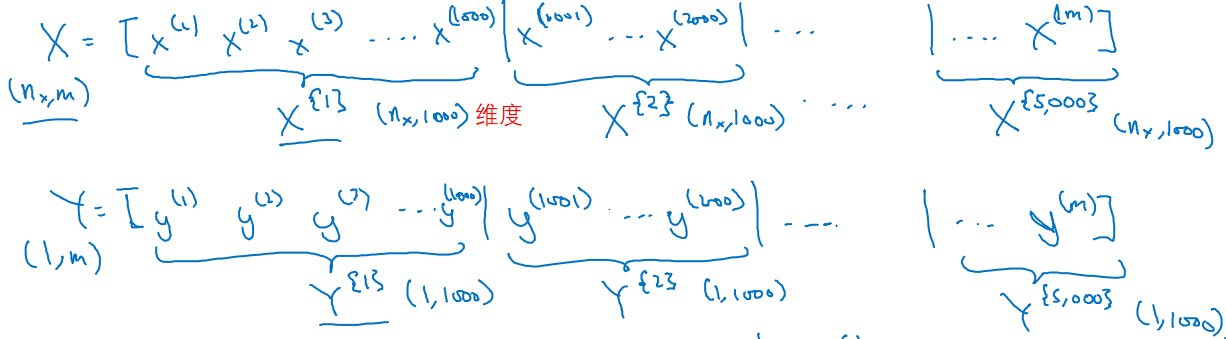

代码：  
一个for循环就是一个遍历（epoch)
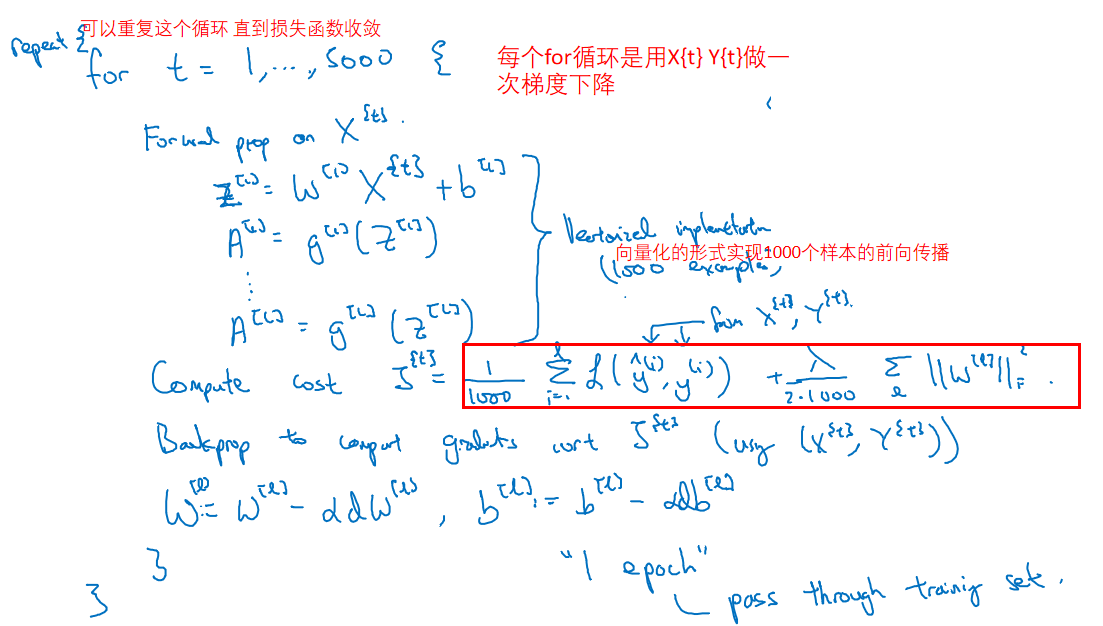

## 理解mini-batch
对于一般的神经网络模型，使用Batch gradient descent，随着迭代次数增加，cost是不断减小的。然而，使用Mini-batch gradient descent，随着在不同的mini-batch上迭代训练，其cost不是单调下降，而是受类似noise的影响，出现振荡。但整体的趋势是下降的，最终也能得到较低的cost值。
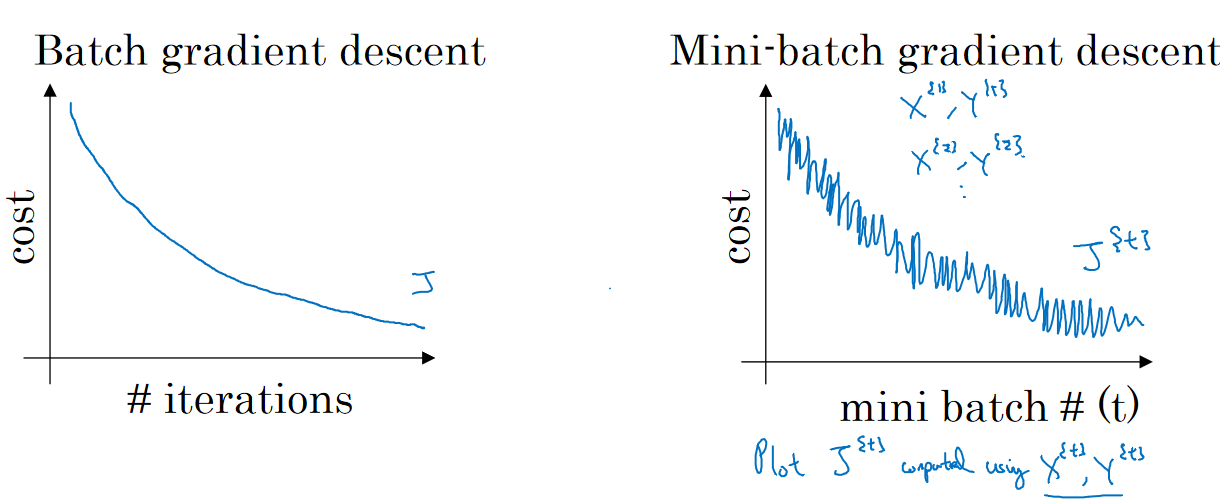

- <font color="#439aa">如果mini-batch size =m：批量梯度下降。</font>
    - 低噪声：因为使用了整个训练集来计算梯度，梯度的估计相对准确，噪声较小。
    - 较大步：每次更新参数时，都是基于整个训练集计算的梯度，因此每一步（梯度更新）会相对较大
- <font color="#439aa">如果mini-batch size =1：随机梯度下降算法。每一条数据都是一个mini-batch。</font>
    - 噪声大：每次参数更新只使用一个样本，因此梯度的估计存在较大的方差，这会导致参数更新的不稳定性。
    - 每次前进速度很快，但是路线曲折，有较大的振荡，最终会在最小值附近来回波动，难以真正达到最小值处。
    - 失去向量加速的机会：由于每次只使用一个样本，无法利用向量和矩阵运算的并行计算能力，从而降低了计算效率。
- mini-batch介于1 ，m之间
  -  一般来说，如果总体样本数量m不太大时，例如m≤200，建议直接使用批量下降。
  - 如果总体样本数量m很大时，batch值一般在64~512之间，是2的幂次方。64，128，256，512。【计算机存储数据一般是2的幂，这样设置可以提高运算速度】
  - 保证每个batch的值比CPU/GPU的内存小

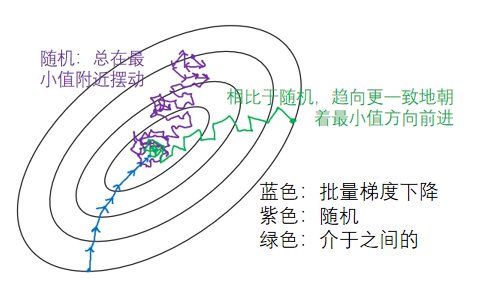

# 指数加权平均Exponentially weighted averages




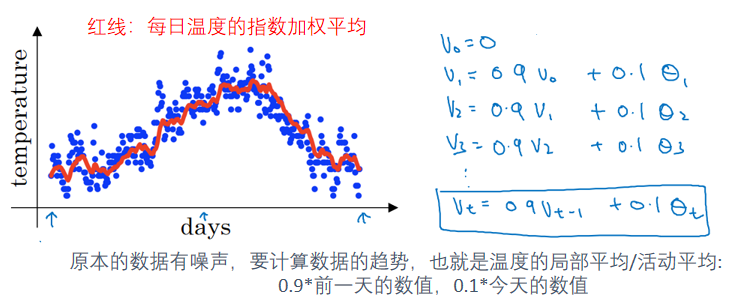

公式是：
$$V_t=\beta V_{t-1}+(1-\beta)\theta_t$$
- 当计算这个公式时，可以认为$V_t$近似于$\frac{1}{1-\beta}$天的平均
- 比如当$\beta=0.9$,可以认为是前10天温度的平均值
- $\beta$越大，指数加权平均的天数越多，曲线越平滑。但是同时曲线会右移。
- 随着 𝛽增大，曲线的响应时间延迟，导致数据的变化在平滑曲线上体现得稍晚∴曲线整体会右移

不同的平滑系数会有不同的效果：
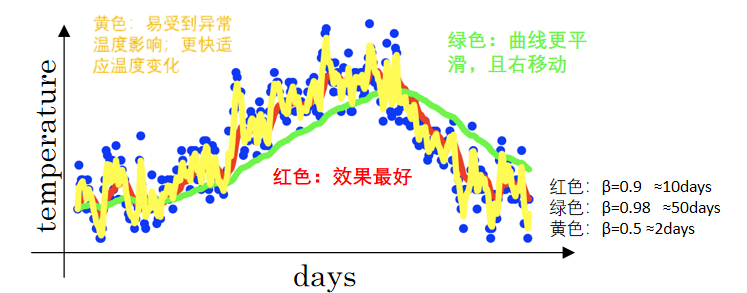

## 偏差修正
- 偏差修正（Bias Correction）是用来修正指数加权平均在初始阶段的偏差问题的。这个问题通常出现在移动平均的前几步计算中，因为初始值往往设定为零或其他非代表性的值，导致初始阶段的移动平均值偏离真实值。
- 通过偏差修正，可以更准确地反映移动平均值，使得在初始阶段的数据也能较好地代表整体趋势。

<font color="purple">实际上，真实曲线如紫色曲线所示。紫色曲线与绿色曲线的区别是，紫色曲线开始的时候相对较低一些。这是因为开始时我们设置V0=0，所以初始值会相对小一些，直到后面受前面的影响渐渐变小，趋于正常。</font>
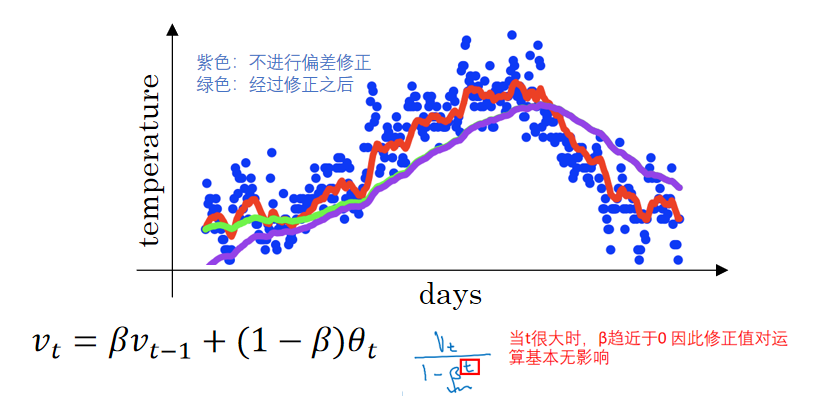



偏差修正公式

指数加权移动平均的计算公式是：
$$ v_t = \beta v_{t-1} + (1 - \beta) \theta_t $$

其中，$ v_t $是时间  $t$的移动平均值，$\beta $ 是平滑系数，$\theta_t$ 是时间 t  的实际观测值。

为了修正前期移动平均值的偏差，可以使用以下公式：
$$ \hat{v}_t = \frac{v_t}{1 - \beta^t} $$

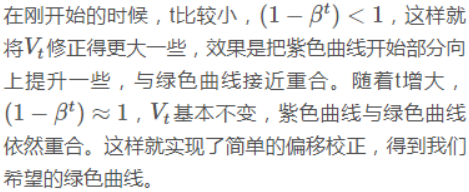
- 值得一提的是，机器学习中，偏移校正并不是必须的。因为，在迭代一次次数后（t较大），Vt受初始值影响微乎其微，紫色曲线与绿色曲线基本重合。所以，一般可以忽略初始迭代过程，等到一定迭代之后再取值，这样就不需要进行偏移校正了。

# 动量梯度下降
- 动量梯度下降算法，其速度要比传统的梯度下降算法快很多。做法是在每次训练时，对梯度进行指数加权平均处理，然后用得到的梯度值更新权重W和常数项b。
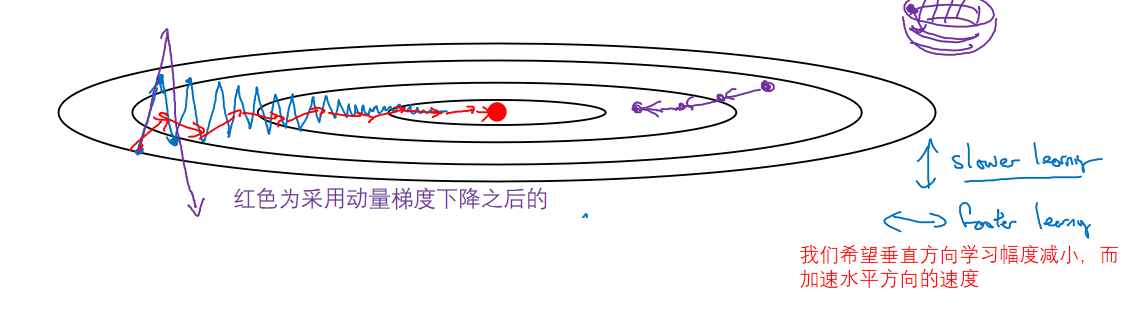

② 原始的梯度下降算法如上图蓝色折线所示。在梯度下降过程中，梯度下降的振荡较大，尤其对于W、b之间数值范围差别较大的情况。

③ 此时每一点处的梯度只与当前方向有关，产生类似折线的效果，前进缓慢。而如果对梯度进行指数加权平均，这样使当前梯度不仅与当前方向有关，还与之前的方向有关，这样处理让梯度前进方向更加平滑，减少振荡，能够更快地到达最小值处。

公式：
首先初始化$V_{dW},V_{db}$为0
1. 计算当前 mini-batch 的梯度：
   $$
   \Delta W, \Delta b
   $$

2. 计算动量项：【动量项$ V_{dW}$：就像物理中的动量一样，保留了之前梯度的方向和大小，使得模型在更新参数时更有惯性。】

   $$
   V_{dW} = \beta V_{dW} + (1 - \beta) \Delta W
   $$
   
   $$
   V_{db} = \beta V_{db} + (1 - \beta) \Delta b
   $$

3. 更新权重和偏置：
   $$
   W = W - \alpha V_{dW}
   $$
   
   $$
   b = b - \alpha V_{db}
   $$


优点：
- 加速收敛：通过结合前几次梯度，动量梯度下降能在陡峭的方向上快速收敛，在平缓的方向上稳定前进。

注意：现在就有两个超参数：α,β。都可以在验证机上调整。（β一般是0.9）。β越大意味着前一步更新的影响更加持久，使得算法在参数空间内移动更加平滑。

# RMSprop
可以实现学习率自适应调整，变化较大的梯度分量上的学习率会自动减小，变化较小的梯度分量上的学习率会自动增大。

$$
\begin{gathered}
S_W=\beta S_{d W}+(1-\beta) d W^2 \\
S_b=\beta S_{d b}+(1-\beta) d b^2 \\
W:=W-\alpha \frac{d W}{\sqrt{S_W+\epsilon}}, b:=b-\alpha \frac{d b}{\sqrt{S_b+\epsilon}}
\end{gathered}
$$
*  平方操作是逐元素的平方操作;$+\epsilon$一般取$10^{-8}$，是为了保证分母不为0


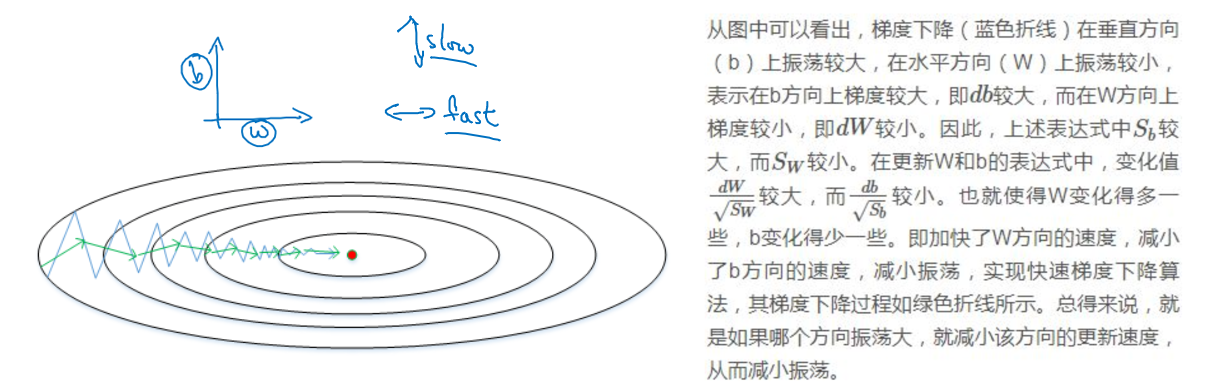

好处：降低梯度下降和小批量梯度下降中的振荡。。并且能使用更大的学习率α

# ADAM 算法--适应性矩估计

- 本质上是将动量算法和RMSprop结合起来
$$
V_{d W}=0, S_{d W}, V_{d b}=0, S_{d b}=0
$$

On iteration $t$ :
Compute $d W, d b$
$$
\begin{aligned}
& V_{d W}=\beta_1 V_{d W}+\left(1-\beta_1\right) d W, V_{d b}=\beta_1 V_{d b}+\left(1-\beta_1\right) d b \\
& S_{d W}=\beta_2 S_{d W}+\left(1-\beta_2\right) d W^2, S_{d b}=\beta_2 S_{d b}+\left(1-\beta_2\right) d b^2 \\
& V^{corrcted}_{dw}=v_{dw}/(1-\beta_1^t) , V^{corrcted}_{db}=v_{db}/(1-\beta_1^t) \\
& S^{corrcted}_{dw}=v_{dw}/(1-\beta_2^t) , S^{corrcted}_{db}=v_{db}/(1-\beta_2^t) \\
& w:=w-\alpha \frac{ V^{corrcted}_{dw}}{\sqrt{ S^{corrcted}_{dw}}+\epsilon} ,b:=b-\alpha \frac{ V^{corrcted}_{db}}{\sqrt{ S^{corrcted}_{db}}+\epsilon}
\end{aligned}
$$

对于上述的几个超参数，
- α：需要进行调整
- β1：一般是0.9
- β2：可取0.999
- ε：如何选择影响不大，不用深入研究，推荐$10^{-8}$作为默认值。实际上β1 β2一般也不会去研究

# 学习率衰减learning rate decay
在学习的初始步骤，可以采取大得多的步长。**随着学习率降低，α变小**，步长也会逐渐变小。所以最终将围绕着离极小值点更近的区域摆动。         
公式1：
$$\alpha=\frac{1}{1+decay\_rate * epoch}\alpha_0$$
- decay rate是另一个超参数，可能需要调整

还有许多别的公式：
$$
\begin{gathered}
\alpha=0.95^{\text {epoch }} \cdot \alpha_0 \\
\alpha=\frac{k}{\sqrt{\text { epoch }}} \cdot \alpha_0 \quad \text { or } \quad \frac{k}{\sqrt{t}} \cdot \alpha_0
\end{gathered}
$$
- 其中t是mini-batch小批量的次数
- 除此之外，还可以设置α为关于t的离散值，随着t增加，α呈阶梯式减小。当然，也可以根据训练情况灵活调整当前的α值，但会比较耗时间。

# 理解局部最优问题
在使用梯度下降算法不断减小cost function时，可能会得到局部最优解（local optima）而不是全局最优解（global optima）。之前我们对局部最优解的理解是形如碗状的凹槽，如下图左边所示。但是在神经网络中，local optima的概念发生了变化。


- 对于一个高维函数，函数中大部分梯度为零的点，实际上并不是局部最优，而是鞍点saddle point。
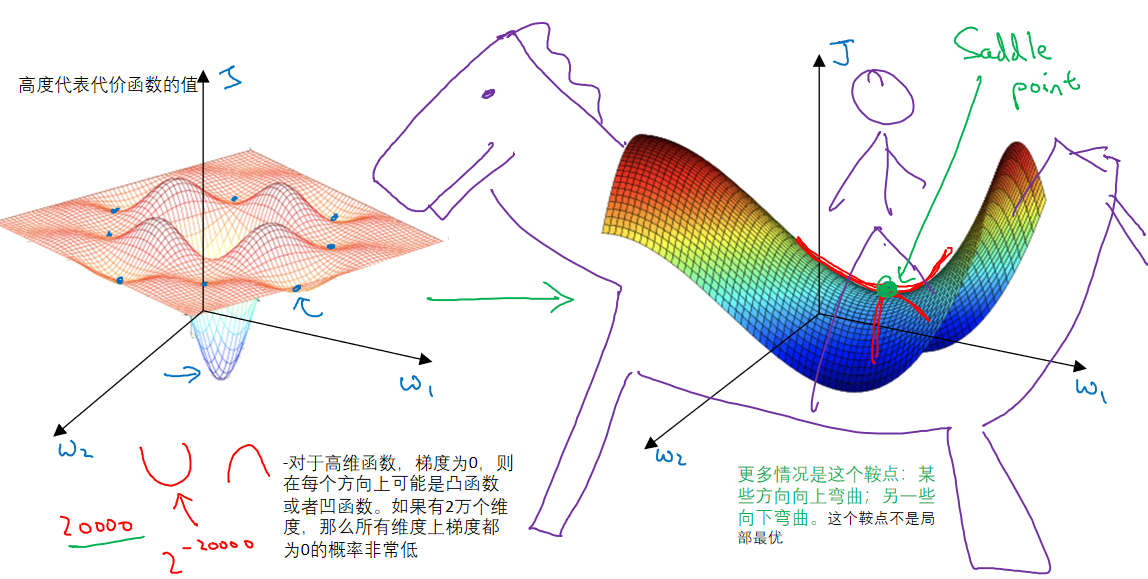

- 停滞区plateau是个问，让学习过程变得很慢：类似马鞍状的plateaus会降低神经网络学习速度。Plateaus是梯度接近于零的平缓区域，如下图所示。在plateaus上梯度很小，前进缓慢，到达saddle point需要很长时间。

- 在这些场景下，更复杂的算法，如Adam算法可以加快沿停滞区向下移动然后离开的速度。

- 到达saddle point后，由于随机扰动，梯度一般能够沿着图中红色箭头，离开saddle point，继续前进，只是在plateaus上花费了太多时间。
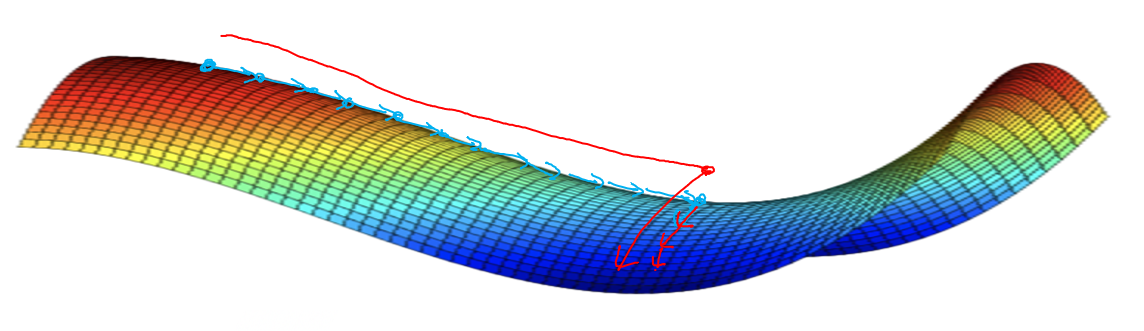

# ⭐测试题目


1. 当输入从第8个mini-batch的第7个的例子的时候，你会用哪种符号表示第3层的激活？

答案：

A.【 √ 】$ a^{[3]\{8\}(7)}$

-------
2. 关于mini-batch的说法哪个是正确的？

A. 【  】mini-batch迭代一次（计算1个mini-batch），要比批量梯度下降迭代一次快

B. 【  】用mini-batch训练完整个数据集一次，要比批量梯度下降训练完整个数据集一次快

C. 【  】在不同的mini-batch下，不需要显式地进行循环，就可以实现mini-batch梯度下降，从而使算法同时处理所有的数据（矢量化）

答案：

A.【 √ 】mini-batch迭代一次（计算1个mini-batch），要比批量梯度下降迭代一次快

<font color='purple'>解释：
    B 虽然单次计算mini-batch梯度所需的时间比计算整个数据集的梯度时间短，但要完成对整个数据集的训练，mini-batch需要进行多次迭代。每次mini-batch迭代都涉及模型参数的更新、数据的加载等操作，这些操作在每个mini-batch迭代中都会进行，而批量梯度下降只需要一次。这些额外的操作开销累积起来，可能使mini-batch训练整个数据集一次的时间比批量梯度下降训练整个数据集一次的时间长。   
    C 在不同的mini-batch下仍需要显式地进行循环.矢量化技术主要用于加速单个mini-batch的计算，即通过将操作转化为矩阵和向量运算来提高效率,但仍然需要循环遍历整个数据集，将其分割成多个mini-batch
    </font>

--------
3. 您在伦敦温度数据集上使用指数加权平均， 使用以下公式来追踪温度：$  v_t=\beta v_{t-1}+(1-\beta)\theta_t $
 。下图中红线使用的是$ \beta=0.9$来计算的。当你改变β时，你的红色曲线会怎样变化？（选出所有正确项）
 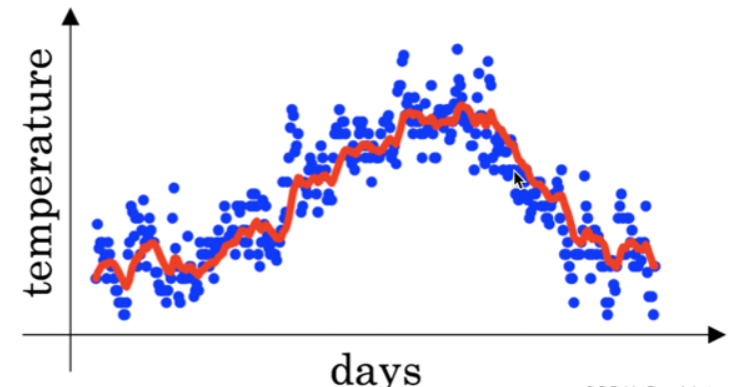
 答案：

B.【 √ 】增加β ，红色线会略微右移

C.【 √ 】减小β ，红线会更加震荡

------------
4. 下图中的曲线是由：梯度下降，动量梯度下降（β = 0.5 ）和动量梯度下降（β = 0.9）。哪条曲线对应哪种算法？
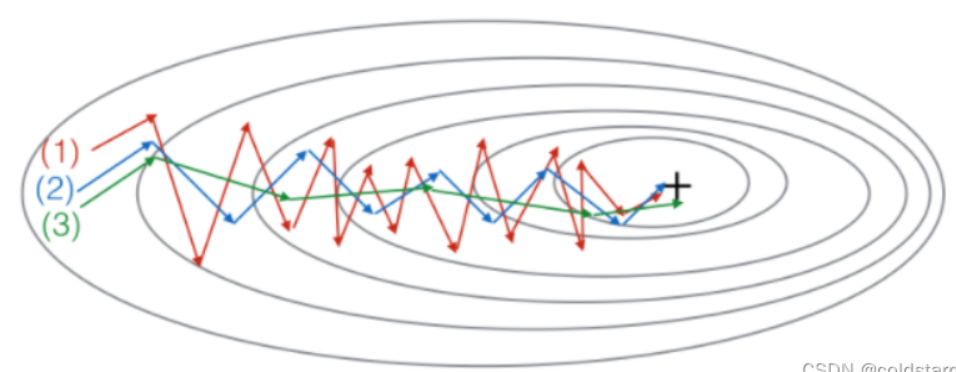
答案：

B.【 √ 】(1)是梯度下降；(2)是动量梯度下降（β = 0.5）；(3)是动量梯度下降（β = 0.9 ）


分析:
- 梯度下降（Gradient Descent）：没有动量项，因此更新的方向完全由当前梯度决定。通常会看到曲线在目标区域附近震荡很多，尤其是在狭窄的谷地中。

- 动量梯度下降（Momentum Gradient Descent）：引入动量项，使得更新方向不仅由当前梯度决定，还会受到之前更新方向的影响。动量参数 𝛽的大小决定了动量效应的强弱：   
    - β=0.5：动量效应较弱，但仍有一定的平滑效果。
    - β=0.9：动量效应较强，更新路径更加平滑，减少了震荡，并加快了收敛。
    
<font color='purple'> 图中红色曲线（1）：有显著的震荡现象，尤其是在接近目标区域（中心点）时。这种震荡特性典型地与纯梯度下降算法相关，因为它没有动量项，容易在狭窄的谷地中来回摆动。

-----------
5. 关于Adam算法，下列哪一个陈述是错误的？

A. 【  】Adam结合了Rmsprop和动量的优点

B. 【  】Adam中的学习率超参数α通常需要调整

C. 【  】我们经常使用超参数的“默认”值$\beta_1=0,9,\beta_2=0.999,\epsilon=10^{-8}$

D. 【  】Adam应该用于批梯度计算，而不是用于mini-batch

答案：

D.【 √ 】Adam应该用于批梯度计算，而不是用于mini-batch

<font color='purple'>分析：  
D 错误,错误：Adam算法设计上是用于mini-batch梯度下降的。它能够通过自适应地调整每个参数的学习率，从而在训练深度神经网络时表现出色。实际上，Adam被广泛应用于mini-batch而不是全批次的梯度下降中，因为全批次梯度下降计算量太大，不适用于大规模数据集。